# Autoscaling configurations for publication

In [5]:
# Basic imports
%matplotlib widget
from numpy import mean  
from ascal import AscalConfig, Ascal
from examples import aws_eu_west_1_c5m5r5
import csv
import random

In [6]:
from math import sqrt

def sqrt_noise(x):
    delta = int(round(0.2*sqrt(x)))
    noise = random.randint(-delta, delta)
    return noise

def linear_noise(x):
    delta = int(round(0.1*x))
    noise = random.randint(-delta, delta)
    return noise

def generate_trace_file(file="trace.txt", duration=24*60, offset=0, ramp_up=0.25, plateau=0.5, 
                        ramp_down=0.25, start_value=1, end_value=10, noise=lambda x: 0):

    # Segment durations
    ramp_up = int(round(duration * ramp_up))
    plateau = int(round(duration * plateau))
    ramp_down = int(round(duration * ramp_down))
    valley = duration - (ramp_up + plateau + ramp_down)
    assert valley >= 0, "Duration too short for the given ramp/plateau proportions"

    def add_noise(value):
        return value + noise(value)

    values = []

    # Initial valley
    initial_valley = valley // 2
    for _ in range(initial_valley):
        noisy = add_noise(start_value)
        values.append(noisy)

    # Ramp up
    for i in range(ramp_up):
        base = start_value + (end_value - start_value) * i / (ramp_up - 1)
        noisy = add_noise(round(base))
        values.append(noisy)

    # Plateau
    for _ in range(plateau):
        noisy = add_noise(end_value)
        values.append(noisy)

    # Ramp down
    for i in range(ramp_down):
        base = end_value - (end_value - start_value) * i / (ramp_down - 1)
        noisy = add_noise(round(base))
        values.append(noisy)

    # Final valley
    for _ in range(valley - initial_valley):
        noisy = add_noise(start_value)
        values.append(noisy)

    # Save CSV
    values = values[-offset:] + values[:-offset]  # Apply offset
    with open(file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["value"])
        for v in values:
            writer.writerow([v])


In [7]:
# Configuration files defining ASCAL problems
config_files = [
    "config_hpa_ca.yaml", 
    "config_fcma_reactive.yaml", 
    "config_fcma_predictive.yaml",
    "config_hpa_ca_fcma_reactive.yaml",
    "config_hpa_ca_fcma_predictive.yaml",
    "config_hpa_ca_fcma_reactive_upgrade.yaml",
    "config_hpa_ca_fcma_predictive_upgrade.yaml",
    ] 
log_file = None

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
Time: 2500 s
Time: 2600 s
Time: 2700 s
Time: 2800 s
Time: 2900 s
Time: 3000 s
Time: 3100 s
Time: 3200 s
Time: 3300 s
Time: 3400 s
Time: 3500 s
Time: 3600 s
Time: 3700 s
Time: 3800 s
Time: 3900 s
Time: 4000 s
Time: 4100 s
Time: 4200 s
Time: 4300 s
Time: 4400 s
Time: 4500 s
Time: 4600 s
Time: 4700 s
Time: 4800 s
Time: 4900 s
Time: 5000 s
Time: 5100 s
Time: 5200 s
Time: 5300 s
Time: 5400 s
Time: 5500 s
Time: 5600 s
Time: 5700 s
Time: 5800 s
Time: 5900 s
Time: 6000 s
Time: 6100 s
Time: 6200 s
Time: 6300 s
Time: 6400 s
Time: 6500 s
Time: 6600 s
Time: 6700 s
Time: 6800 s
Time: 6900 s
Time: 7000 s
Time: 7100 s
Time: 7200 s
Time: 7300 s
Ti

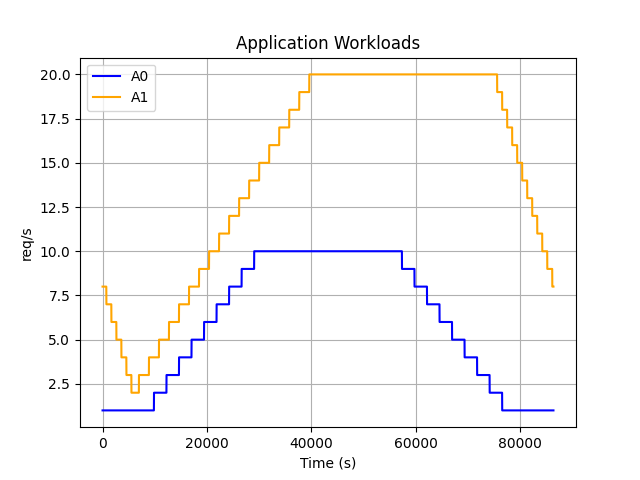

-----------------------------------------------------------------
Plotting results for configuration file: config_hpa_ca.yaml
-----------------------------------------------------------------


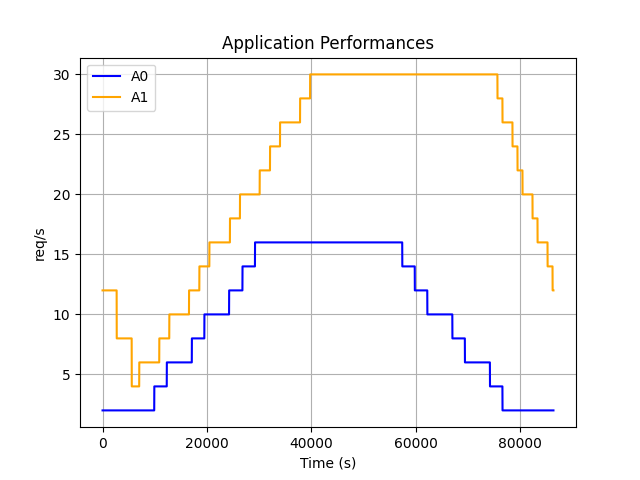

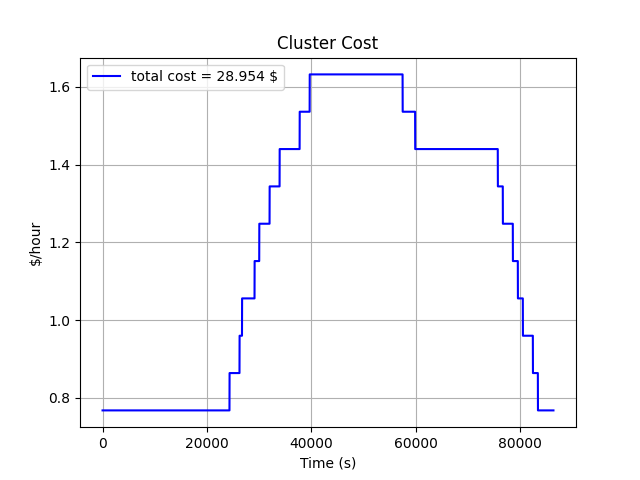

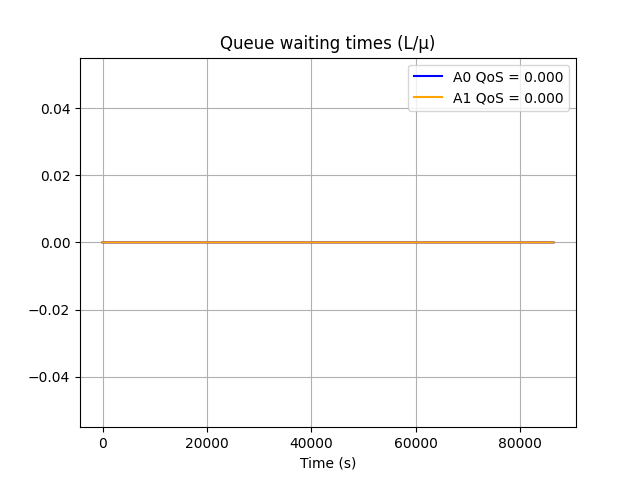

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
You can check the CBC log at /tmp/5dd303ddcee24c81a5ea0a8e597d4f6c-pulp.lp.log
You can check the CBC log at /tmp/891afb481bf745a9a2c9ab7b47cd3674-pulp.lp.log
Time: 100 s
You can check the CBC log at /tmp/77ad862bc5e54d7c9d3db28c48fbf253-pulp.lp.log
You can check the CBC log at /tmp/7b6d2223fd0a446297bf1b072e414757-pulp.lp.log
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/6ed5a67b563c424db1200dc2f085b3e1-pulp.lp.log
You can check the CBC log at /tmp/9ce2fc17edf64e58a51f89a6b308e038-pulp.lp.log
Time: 400 s
You can check the CBC log at /tmp/c253401f6eb34cbeb318337f407edf40-pulp.lp.log
You can check the CBC log at /tmp/ac89edf3e74c4307bab0a4017f19cd55-pulp.lp.log
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/acbd71c5a9704c9a8f637745b2226a1c-pulp.lp.log
You can check the CBC log at /tmp/e50819a6d66847c9b92a9424ef212e82-pulp.lp.log
Time: 700 s
You can check the CBC log at /tmp/60dfaef98a8f4ec7a7009f12fa77ed14-p

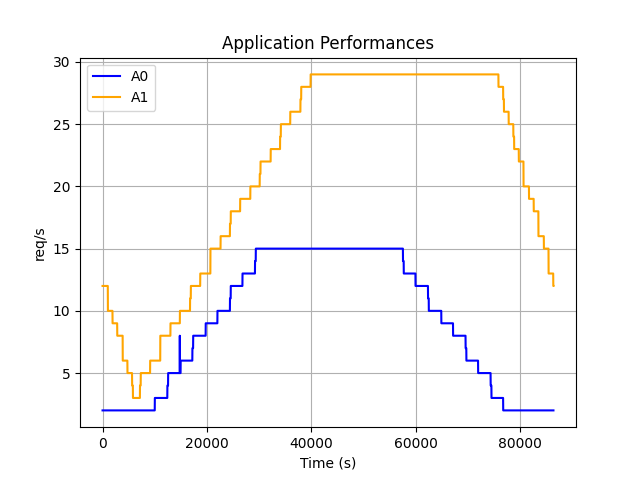

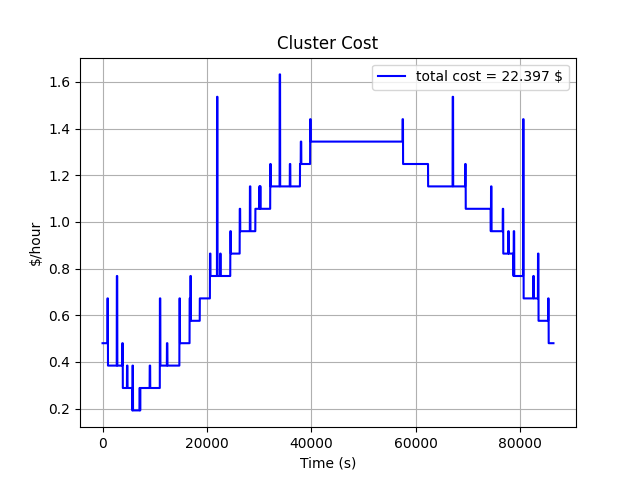

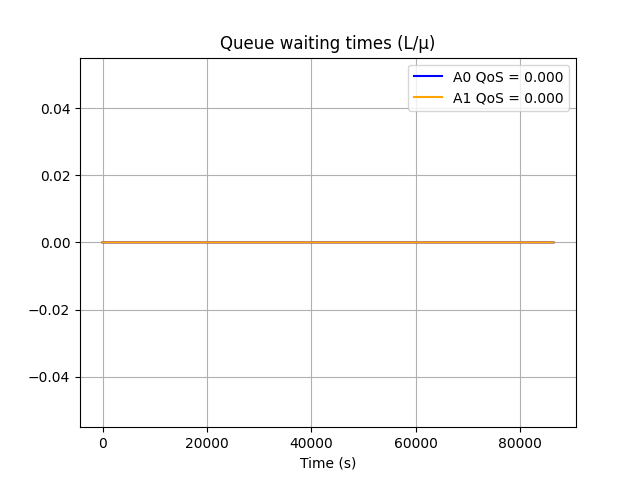

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
You can check the CBC log at /tmp/75bbd8ddf7a74307ad89864ac3911919-pulp.lp.log
You can check the CBC log at /tmp/ccded5bb5bdf468fa2921448a70f73a6-pulp.lp.log
You can check the CBC log at /tmp/f314c7dd444b4ae392ff550d41dbec68-pulp.lp.log
You can check the CBC log at /tmp/309fb26c0ab34ac88ba23041ac7356da-pulp.lp.log
You can check the CBC log at /tmp/1f096ba7308040b9b940babdf84b7ab0-pulp.lp.log
You can check the CBC log at /tmp/aba6b83774684a9a8569bb3fc68b192b-pulp.lp.log
Time: 100 s
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/f5a0fc1037414430be53fea3c3c8f8e5-pulp.lp.log
You can check the CBC log at /tmp/0036d3457d2a4f22b0816284018059f9-pulp.lp.log
You can check the CBC log at /tmp/82962d80516646a7b79c0bb6b81d0473-pulp.lp.log
You can check the CBC log at /tmp/984d5d7c4e0c468d91ab907c47a1bc8b-pulp.lp.log
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/b67a0176b3424f06afd66b9e02b3c0b4-pulp.lp.log
Y

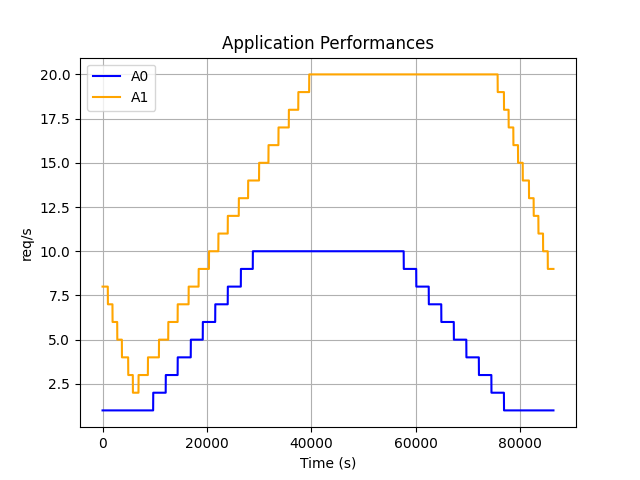

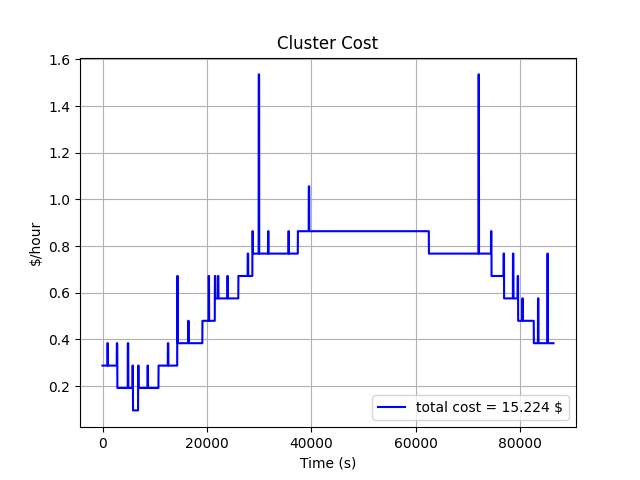

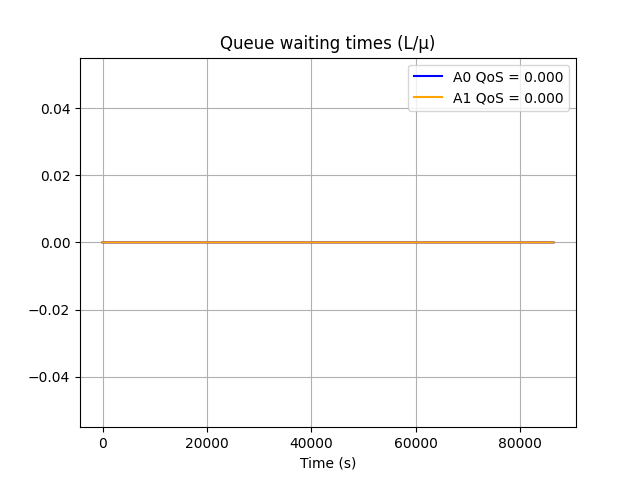

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/9603ef043dff4a5586733e7c2424283d-pulp.lp.log
You can check the CBC log at /tmp/3b4b458f80244e4a910129e43ebef160-pulp.lp.log
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
You can check the CBC log at /tmp/a87f1eabbb184cf49edbbff3167292fb-pulp.lp.log
You can check the CBC log at /tmp/58b17b664e214138806891511a13ef6b-pulp.lp.log
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/616e8803d41a4a81a3cd248048ffc1e1-pulp.lp.log
You can check the CBC log at /tmp/91b84781e54f48cebe0551d27f4c3038-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/9e4b6292a7b84896b950bb3a3948db97-pulp.lp.log
You can check the CBC log at /tmp/1d909e884cf346368b44df27909c4e07-pulp.lp.log
Time: 2

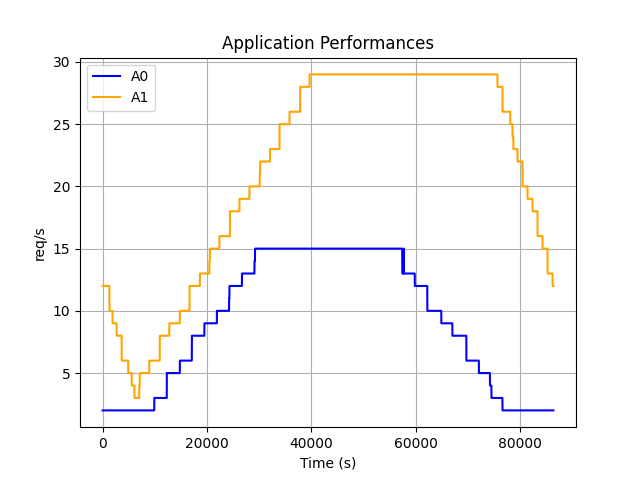

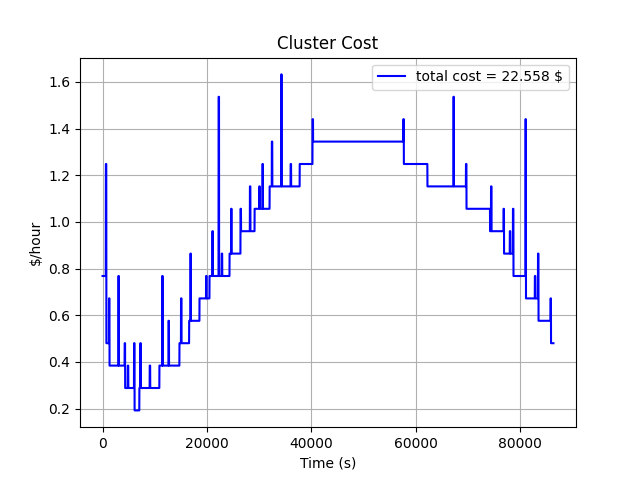

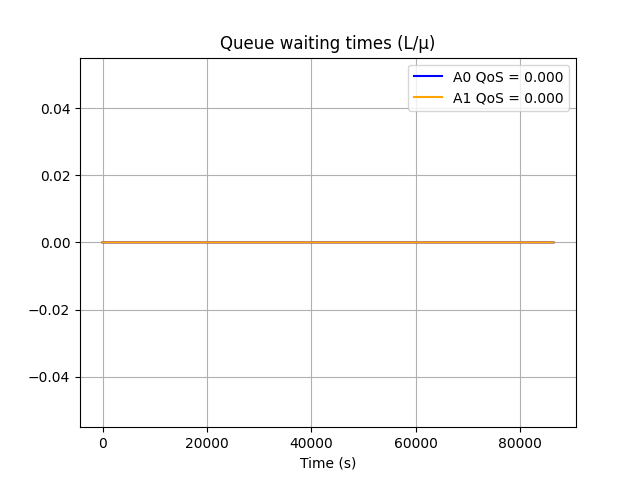

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
You can check the CBC log at /tmp/2e630756741e46dea9bd4bf7dbdeaccb-pulp.lp.log
You can check the CBC log at /tmp/bc30e396251c4de6954f23821a14ce54-pulp.lp.log
You can check the CBC log at /tmp/d0636b03acec4c3a98870009e592327c-pulp.lp.log
You can check the CBC log at /tmp/8c11dfd72eb44ab496fae402f04ac692-pulp.lp.log
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
You can check the CBC log at /tmp/99c27f7a2b9d49c6965f431f8a87fff5-pulp.lp.log
You can check the CBC log at /tmp/3367a6028b8041d8b5f74b6ddd6a0bae-pulp.lp.log
You can check the CBC log at /tmp/6792738cfc914086a393a230ac4e4879-pulp.lp.log
You can check the CBC log at /tmp/4d5466413c4e4efdaf7d15b5e381f839-pulp.lp.log
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
You can check the CBC log at /tmp/bce907b1ad8d48f4a0c1f2e850c2225d-pulp.lp.log
You can check the CBC log at /tm

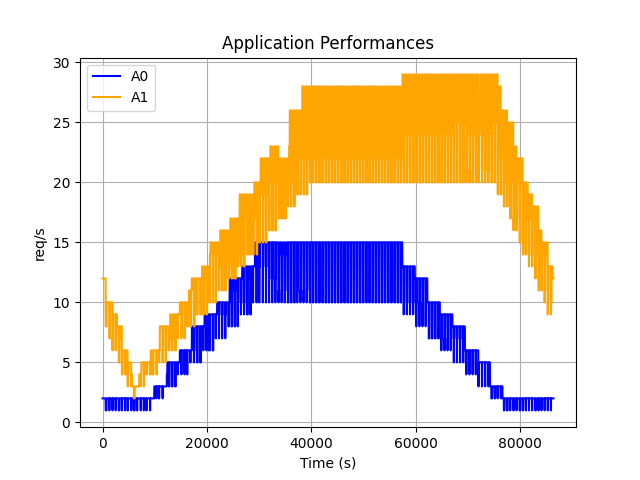

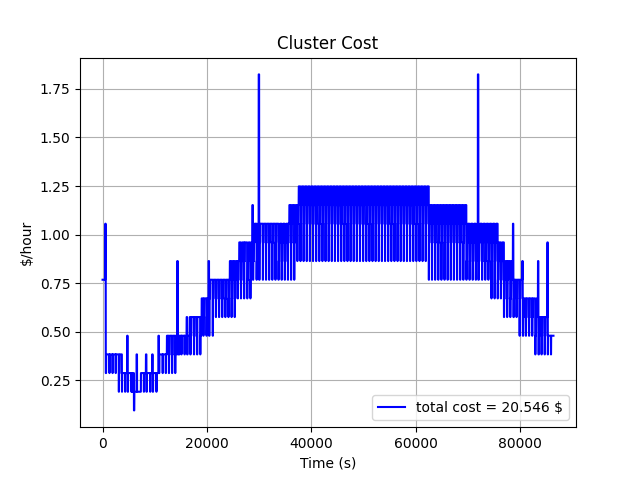

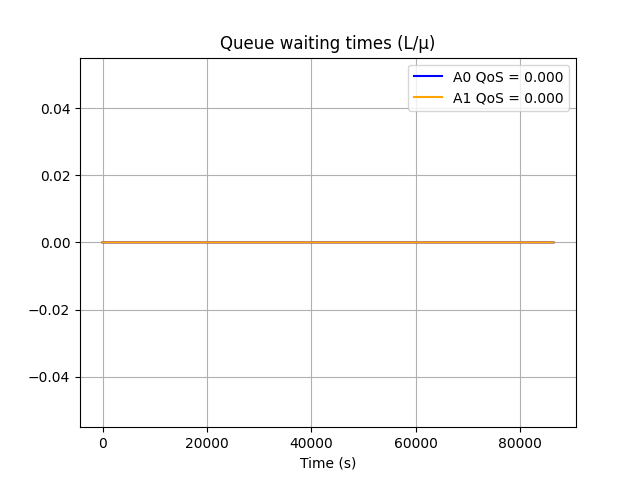

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/d9664ab0ea944a7dbb57c01913ae0309-pulp.lp.log
You can check the CBC log at /tmp/7f4c4814a06c42c280d6fe8159f4ea3a-pulp.lp.log
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
You can check the CBC log at /tmp/cbe492ba807a4adbb39d054b67a03741-pulp.lp.log
You can check the CBC log at /tmp/3d741831d08946c796ffd8d4180a4e5b-pulp.lp.log
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/179813afecfc47b690c1f1bd1b8e6eee-pulp.lp.log
You can check the CBC log at /tmp/317c305e77cf4813a884944d54111188-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/26ec1d374bb3467c80a4331551938351-pulp.lp.log
You can check the CBC log at /tmp/7048105cab1f463eacb3a8158ec61d13-pulp.lp.log
Time: 2

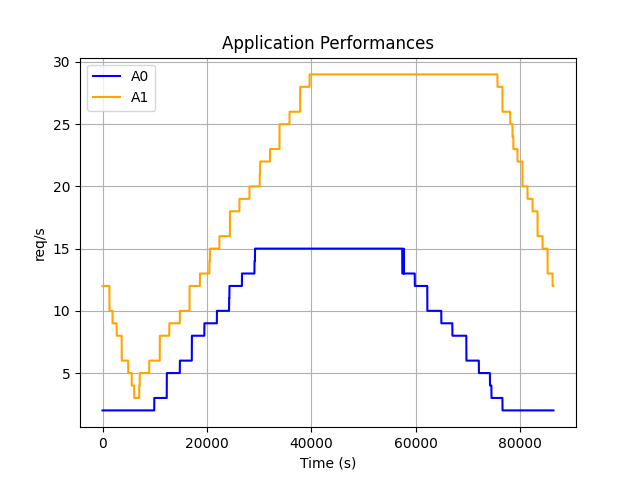

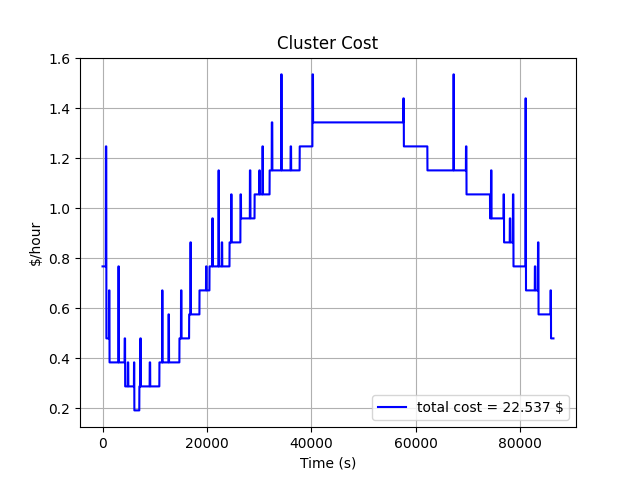

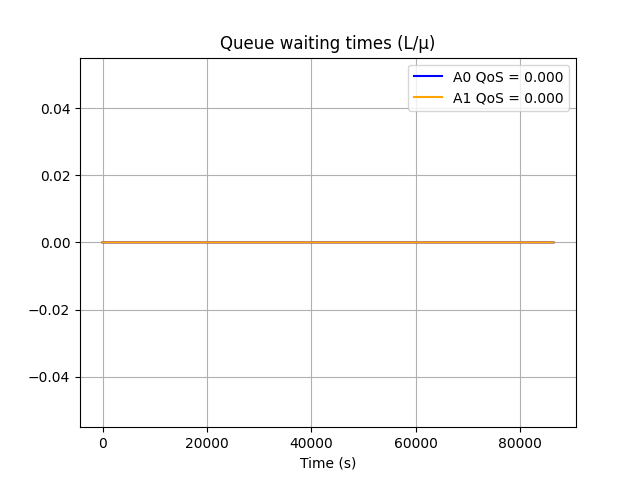

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
You can check the CBC log at /tmp/17695ba23a4c4e9189bc9db0de7d2829-pulp.lp.log
You can check the CBC log at /tmp/2fc631d75dd743fa896af37d4798769f-pulp.lp.log
You can check the CBC log at /tmp/6181e4b845d34e0ba2cfa3de05bcae84-pulp.lp.log
You can check the CBC log at /tmp/b45a10eca05c404c8c4610b58f4c5a63-pulp.lp.log
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
You can check the CBC log at /tmp/cf815159c0384c8b8fa34e3c5f3d7248-pulp.lp.log
You can check the CBC log at /tmp/59c8bbe5a5a5474897ce96211f8aabe0-pulp.lp.log
You can check the CBC log at /tmp/cd73ef6ef50b423085a6afaeb93c5c06-pulp.lp.log
You can check the CBC log at /tmp/97c0c26c4a3744c2b052c41b74eb3d3a-pulp.lp.log
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
You can check the CBC log at /tmp/37d8606b032a42749cd6ab9780cef3e8-pulp.lp.log
You can check the CBC log at /tm

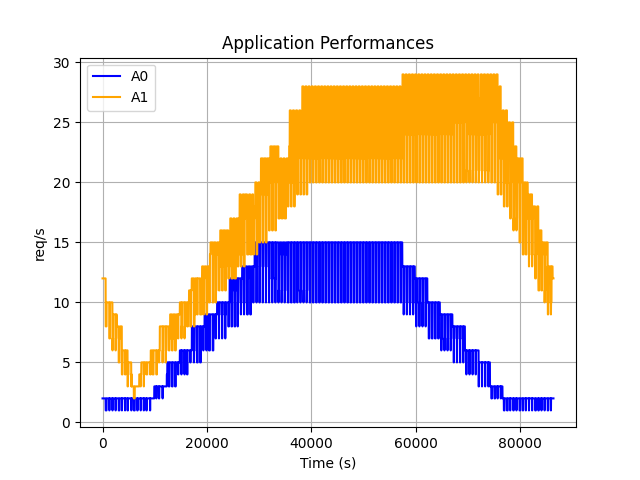

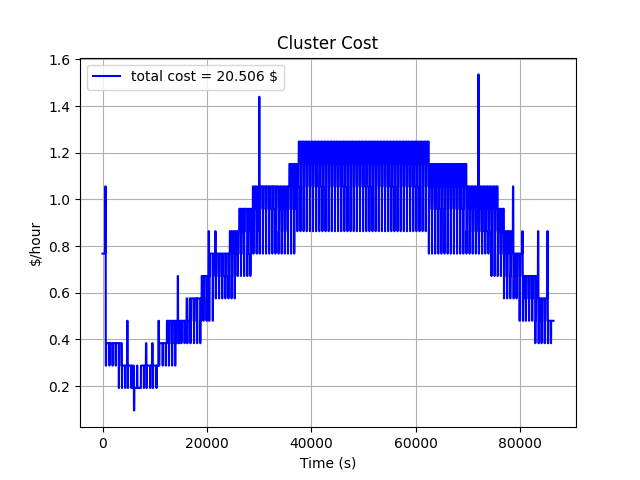

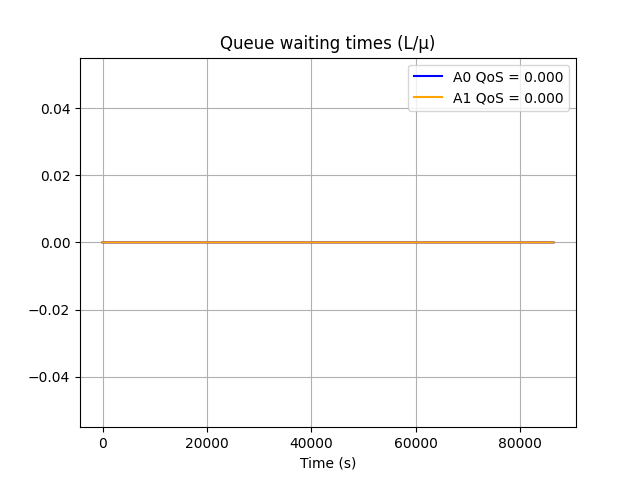

In [8]:
# Generate the trace file
generate_trace_file(file="trapezoid1.csv", duration=24*60, offset=0, ramp_up=0.25, plateau=0.3, 
                    ramp_down=0.25, start_value=1, end_value=10)
generate_trace_file(file="trapezoid2.csv", duration=24*60, offset=100, ramp_up=0.4, plateau=0.4, 
                    ramp_down=0.2, start_value=2, end_value=20)

# Simulate each configuration file
for config_file in config_files[:]:  # Change to config_files to run all configurations
    # Read the problem configuration file and validate it
    # Note that it is possible to validate any ASCAL configuration with method AscalConfig.validate_config()
    ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)

    # Create the autoscaling problem
    ascal_problem = Ascal(ascal_config, log=log_file)

    # Last time that can be simulated (last time in the trace)
    # Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
    last_time = ascal_problem.last_time 
    print(f'Time range of the simulation: 0 - {last_time} seconds')

    # Run the autoscaling problem until the end. The argument of run() method is the last simulation time in seconds
    # Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
    ascal_problem.run()

    # Get queue waiting times assuming each container is a server in an heterogenous D/D/m queue
    queue_waiting_times = ascal_problem.get_queue_waiting_times()
    avgs = {
        app_name: mean(waiting_times)
        for app_name, waiting_times in queue_waiting_times.items()
    }
    for app_name in dict(queue_waiting_times):
        queue_waiting_times[f"{app_name} QoS = {avgs[app_name]:.3f}"] = queue_waiting_times.pop(app_name)

    # Plot workloads
    if config_file == config_files[0]:
        ascal_problem.plot(ascal_problem.get_workloads(), "Application Workloads", "req/s")

    # Plot autoscaling results
    print(f'-----------------------------------------------------------------')
    print(f'Plotting results for configuration file: {config_file}')
    print(f'-----------------------------------------------------------------')
    ascal_problem.plot(ascal_problem.get_performances(), "Application Performances", "req/s")
    cluster_cost = ascal_problem.get_cluster_cost()
    total_cost_str = f"total cost = {sum(cluster_cost)/3600:.3f} $"
    ascal_problem.plot({total_cost_str: cluster_cost}, "Cluster Cost", "$/hour")
    ascal_problem.plot(queue_waiting_times, "Queue waiting times (L/μ)")